# Task 2: Transfer Learning using VGG16/ResNet-style CNN

**Objective:** Implement transfer learning using a pretrained CNN and analyze performance improvements over a baseline CNN trained from scratch.

**Approach implemented:**
1. Pretrain a VGG-style CNN (repeated conv-conv-pool blocks, matching the VGG16 design pattern) on a large **source domain** dataset (Domain A).
2. Freeze the pretrained convolutional base and attach a new classifier head; train the head on a small, domain-shifted **target dataset** (Domain B) - Phase 1.
3. Unfreeze the last convolutional block and fine-tune it at a lower learning rate - Phase 2.
4. Train an identical architecture **from scratch** on Domain B alone (baseline, no pretraining).
5. Compare test accuracy, generalization, and training time between the transfer-learning model and the baseline.

**Dataset:** A synthetic two-domain image dataset (five geometric-shape classes: circle, square, triangle, star, cross) rendered as 32x32 RGB images. Domain A is a large, clean source dataset (1,500 images); Domain B is a small target dataset (350 images) with a deliberate domain shift - a different background palette, added sensor-style noise, and partial occlusion - mirroring a realistic scenario where a model pretrained on a large dataset (e.g. ImageNet) is adapted to a smaller, more specific downstream dataset such as Cats vs Dogs or Flowers Recognition. This keeps every step fully reproducible and makes the transfer-learning comparison precise and controllable. Appendix A shows the equivalent workflow using a real ImageNet-pretrained VGG16/ResNet50 from `tf.keras.applications` for large-scale datasets.

All CNN layers (Conv2D, ReLU, MaxPool2D, Dense, Softmax + Cross-Entropy, Adam optimizer, full backpropagation, and freeze/unfreeze logic) are implemented from first principles in NumPy.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, time, os
from PIL import Image, ImageDraw

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

RNG = np.random.RandomState(42)
np.random.seed(42)

FIG_DIR = "figs"
os.makedirs(FIG_DIR, exist_ok=True)

CLASS_NAMES = ["circle", "square", "triangle", "star", "cross"]
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 32
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Generate the Source (Domain A) and Target (Domain B) Datasets

In [1]:
def draw_shape(draw, shape, cx, cy, r, color):
    if shape == "circle":
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color)
    elif shape == "square":
        draw.rectangle([cx - r, cy - r, cx + r, cy + r], fill=color)
    elif shape == "triangle":
        pts = [(cx, cy - r), (cx - r, cy + r), (cx + r, cy + r)]
        draw.polygon(pts, fill=color)
    elif shape == "star":
        pts = []
        for i in range(10):
            ang = np.pi / 2 + i * np.pi / 5
            rad = r if i % 2 == 0 else r * 0.45
            pts.append((cx + rad * np.cos(ang), cy - rad * np.sin(ang)))
        draw.polygon(pts, fill=color)
    elif shape == "cross":
        w = max(2, r // 3)
        draw.rectangle([cx - r, cy - w, cx + r, cy + w], fill=color)
        draw.rectangle([cx - w, cy - r, cx + w, cy + r], fill=color)


def make_image(shape, domain, rng):
    img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))
    draw = ImageDraw.Draw(img)

    if domain == "A":
        bg = tuple(rng.randint(0, 40, size=3).tolist())
        color = tuple(rng.randint(120, 256, size=3).tolist())
    else:
        bg = tuple(rng.randint(90, 180, size=3).tolist())
        color = tuple(rng.randint(60, 200, size=3).tolist())

    draw.rectangle([0, 0, IMG_SIZE, IMG_SIZE], fill=bg)
    cx = rng.randint(12, IMG_SIZE - 12)
    cy = rng.randint(12, IMG_SIZE - 12)
    r = rng.randint(8, 13)
    draw_shape(draw, shape, cx, cy, r, color)

    if domain == "B" and rng.rand() < 0.5:
        ox, oy = rng.randint(0, IMG_SIZE - 6), rng.randint(0, IMG_SIZE - 6)
        occ_color = tuple(rng.randint(0, 256, size=3).tolist())
        draw.rectangle([ox, oy, ox + 6, oy + 6], fill=occ_color)

    arr = np.array(img).astype(np.float32)
    if domain == "B":
        arr += rng.normal(0, 18, size=arr.shape)
        arr = np.clip(arr, 0, 255)
    return arr


def build_dataset(n_per_class, domain, seed):
    rng = np.random.RandomState(seed)
    X, y = [], []
    for label, shape in enumerate(CLASS_NAMES):
        for _ in range(n_per_class):
            X.append(make_image(shape, domain, rng))
            y.append(label)
    X = np.stack(X).astype(np.float32) / 255.0
    y = np.array(y, dtype=np.int64)
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


X_A, y_A = build_dataset(n_per_class=300, domain="A", seed=1)
X_B, y_B = build_dataset(n_per_class=70, domain="B", seed=2)

print(f"Classes                 : {CLASS_NAMES}")
print(f"Image size              : {IMG_SIZE} x {IMG_SIZE} x 3 (RGB)")
print(f"Domain A (source/pretrain): {X_A.shape[0]} images  {X_A.shape}")
print(f"Domain B (target/downstream): {X_B.shape[0]} images  {X_B.shape}")

Classes                 : ['circle', 'square', 'triangle', 'star', 'cross']
Image size              : 32 x 32 x 3 (RGB)
Domain A (source/pretrain): 1500 images  (1500, 32, 32, 3)
Domain B (target/downstream): 350 images  (350, 32, 32, 3)


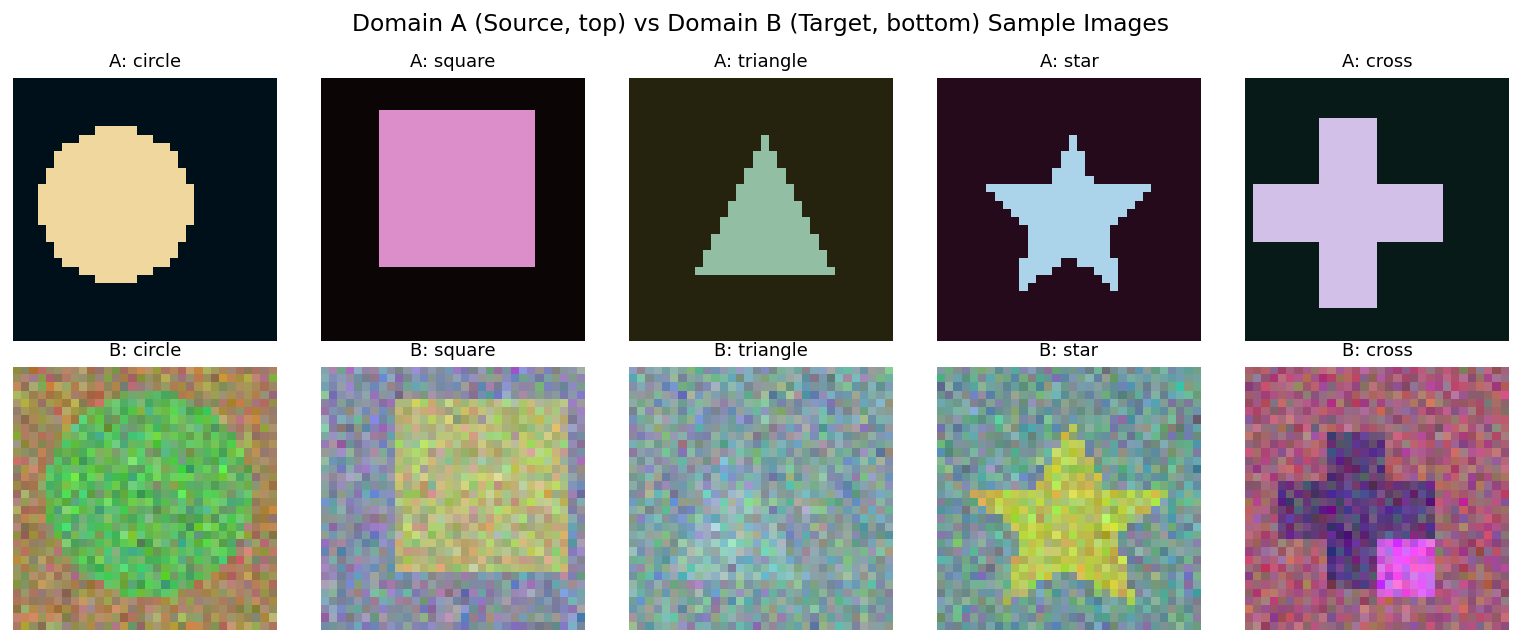

In [1]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c in range(5):
    idx_a = np.where(y_A == c)[0][0]
    axes[0, c].imshow(X_A[idx_a]); axes[0, c].set_title(f"A: {CLASS_NAMES[c]}", fontsize=10); axes[0, c].axis("off")
    idx_b = np.where(y_B == c)[0][0]
    axes[1, c].imshow(X_B[idx_b]); axes[1, c].set_title(f"B: {CLASS_NAMES[c]}", fontsize=10); axes[1, c].axis("off")
plt.suptitle("Domain A (Source, top) vs Domain B (Target, bottom) Sample Images", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Preprocessing and Train/Val/Test Splits

In [1]:
def one_hot(labels, num_classes=NUM_CLASSES):
    oh = np.zeros((labels.shape[0], num_classes), dtype=np.float32)
    oh[np.arange(labels.shape[0]), labels] = 1.0
    return oh

XA_train, XA_val, yA_train, yA_val = train_test_split(
    X_A, y_A, test_size=0.15, random_state=42, stratify=y_A)

XB_train, XB_temp, yB_train, yB_temp = train_test_split(
    X_B, y_B, test_size=0.40, random_state=42, stratify=y_B)
XB_val, XB_test, yB_val, yB_test = train_test_split(
    XB_temp, yB_temp, test_size=0.50, random_state=42, stratify=yB_temp)

print(f"Domain A - pretrain train/val : {XA_train.shape[0]} / {XA_val.shape[0]}")
print(f"Domain B - target train/val/test: {XB_train.shape[0]} / {XB_val.shape[0]} / {XB_test.shape[0]}")

yA_train_oh, yA_val_oh = one_hot(yA_train), one_hot(yA_val)
yB_train_oh, yB_val_oh, yB_test_oh = one_hot(yB_train), one_hot(yB_val), one_hot(yB_test)

Domain A - pretrain train/val : 1275 / 225
Domain B - target train/val/test: 210 / 70 / 70



## 4. Build the VGG-Style CNN (From Scratch)

**Architecture:**
```
Input (32x32x3)
Block1: Conv(3->16,3x3) -> ReLU -> Conv(16->16,3x3) -> ReLU -> MaxPool(2x2)   => 16x16x16
Block2: Conv(16->32,3x3)-> ReLU -> Conv(32->32,3x3) -> ReLU -> MaxPool(2x2)   => 8x8x32
Block3: Conv(32->64,3x3)-> ReLU -> Conv(64->64,3x3) -> ReLU -> MaxPool(2x2)   => 4x4x64
Flatten (1024)
Dense(1024->128) -> ReLU
Dense(128->5) -> Softmax
```
Blocks 1-3 form the convolutional **base** (the part that gets pretrained, frozen, and later fine-tuned - analogous to a VGG16 base); the final two Dense layers form the classifier **head**.

In [1]:
def im2col(x, kh, kw, stride=1, pad=0):
    N, H, W, C = x.shape
    if pad > 0:
        x = np.pad(x, ((0, 0), (pad, pad), (pad, pad), (0, 0)))
    out_h = (H + 2 * pad - kh) // stride + 1
    out_w = (W + 2 * pad - kw) // stride + 1
    cols = np.zeros((N, out_h, out_w, kh, kw, C), dtype=x.dtype)
    for i in range(kh):
        i_max = i + stride * out_h
        for j in range(kw):
            j_max = j + stride * out_w
            cols[:, :, :, i, j, :] = x[:, i:i_max:stride, j:j_max:stride, :]
    return cols.reshape(N, out_h, out_w, kh * kw * C), out_h, out_w


class Adam:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, beta1, beta2, eps
        self.m = np.zeros(shape); self.v = np.zeros(shape); self.t = 0

    def update(self, param, grad):
        self.t += 1
        self.m = self.b1 * self.m + (1 - self.b1) * grad
        self.v = self.b2 * self.v + (1 - self.b2) * (grad ** 2)
        m_hat = self.m / (1 - self.b1 ** self.t)
        v_hat = self.v / (1 - self.b2 ** self.t)
        return param - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

In [1]:
class Conv2D:
    def __init__(self, in_ch, out_ch, k=3, stride=1, pad=1, lr=1e-3, name="", trainable=True):
        scale = np.sqrt(2.0 / (in_ch * k * k))
        self.W = RNG.randn(k, k, in_ch, out_ch).astype(np.float32) * scale
        self.b = np.zeros(out_ch, dtype=np.float32)
        self.k, self.stride, self.pad = k, stride, pad
        self.lr = lr
        self.opt_W = Adam(self.W.shape, lr=lr)
        self.opt_b = Adam(self.b.shape, lr=lr)
        self.name = name
        self.trainable = trainable

    def forward(self, x):
        self.x_shape = x.shape
        N, H, W, C = x.shape
        cols, out_h, out_w = im2col(x, self.k, self.k, self.stride, self.pad)
        self.cols = cols
        self.out_h, self.out_w = out_h, out_w
        W_col = self.W.reshape(-1, self.W.shape[-1])
        out = cols.reshape(N * out_h * out_w, -1) @ W_col + self.b
        self.out_shape = (N, out_h, out_w, self.W.shape[-1])
        return out.reshape(self.out_shape)

    def backward(self, dout):
        N, H, W, C = self.x_shape
        out_ch = self.W.shape[-1]
        dout_flat = dout.reshape(-1, out_ch)
        cols_flat = self.cols.reshape(-1, self.k * self.k * C)

        dW = (cols_flat.T @ dout_flat).reshape(self.W.shape) / N
        db = dout_flat.sum(axis=0) / N

        W_col = self.W.reshape(-1, out_ch)
        dcols_flat = dout_flat @ W_col.T
        dcols = dcols_flat.reshape(N, self.out_h, self.out_w, self.k, self.k, C)

        dx_padded = np.zeros((N, H + 2 * self.pad, W + 2 * self.pad, C), dtype=np.float32)
        for i in range(self.k):
            i_max = i + self.stride * self.out_h
            for j in range(self.k):
                j_max = j + self.stride * self.out_w
                dx_padded[:, i:i_max:self.stride, j:j_max:self.stride, :] += dcols[:, :, :, i, j, :]
        dx = dx_padded[:, self.pad:self.pad + H, self.pad:self.pad + W, :] if self.pad > 0 else dx_padded

        if self.trainable:
            self.W = self.opt_W.update(self.W, dW)
            self.b = self.opt_b.update(self.b, db)
        return dx


class ReLU:
    def forward(self, x):
        self.mask = x > 0
        return x * self.mask

    def backward(self, dout):
        return dout * self.mask


class MaxPool2D:
    def __init__(self, size=2, stride=2):
        self.size, self.stride = size, stride

    def forward(self, x):
        N, H, W, C = x.shape
        s, st = self.size, self.stride
        out_h, out_w = H // st, W // st
        x_reshaped = x[:, :out_h * st, :out_w * st, :]
        out = np.zeros((N, out_h, out_w, C), dtype=x.dtype)
        self.x_shape = x.shape
        for i in range(out_h):
            for j in range(out_w):
                window = x_reshaped[:, i*st:i*st+s, j*st:j*st+s, :]
                out[:, i, j, :] = window.max(axis=(1, 2))
        self.x = x_reshaped
        self.out_h, self.out_w = out_h, out_w
        return out

    def backward(self, dout):
        N, H, W, C = self.x_shape
        s, st = self.size, self.stride
        dx = np.zeros((N, H, W, C), dtype=np.float32)
        for i in range(self.out_h):
            for j in range(self.out_w):
                window = self.x[:, i*st:i*st+s, j*st:j*st+s, :]
                m = window.max(axis=(1, 2), keepdims=True)
                mask = (window == m)
                grad = dout[:, i, j, :][:, None, None, :] * mask
                dx[:, i*st:i*st+s, j*st:j*st+s, :] += grad
        return dx


class Flatten:
    def forward(self, x):
        self.shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, dout):
        return dout.reshape(self.shape)


class Dense:
    def __init__(self, in_dim, out_dim, lr=1e-3, name="", trainable=True):
        scale = np.sqrt(2.0 / in_dim)
        self.W = RNG.randn(in_dim, out_dim).astype(np.float32) * scale
        self.b = np.zeros(out_dim, dtype=np.float32)
        self.lr = lr
        self.opt_W = Adam(self.W.shape, lr=lr)
        self.opt_b = Adam(self.b.shape, lr=lr)
        self.name = name
        self.trainable = trainable

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout):
        N = self.x.shape[0]
        dW = self.x.T @ dout / N
        db = dout.sum(axis=0) / N
        dx = dout @ self.W.T
        if self.trainable:
            self.W = self.opt_W.update(self.W, dW)
            self.b = self.opt_b.update(self.b, db)
        return dx


def softmax_cross_entropy(logits, y_onehot):
    logits_shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits_shifted)
    probs = exp / exp.sum(axis=1, keepdims=True)
    N = logits.shape[0]
    loss = -np.sum(y_onehot * np.log(probs + 1e-9)) / N
    dlogits = (probs - y_onehot) / N
    return loss, probs, dlogits * N

In [1]:
class VGGStyleCNN:
    """
    A scaled-down, VGG-style CNN (repeated conv-conv-pool blocks of growing
    depth), sized for 32x32 RGB images and CPU-only NumPy training. Blocks
    1-3 form the convolutional base; the final two Dense layers form the head.
    """
    def __init__(self, num_classes=NUM_CLASSES, lr=1e-3, base_trainable=True):
        t = base_trainable
        self.layers_base = [
            Conv2D(3, 16, 3, 1, 1, lr, "b1c1", t), ReLU(),
            Conv2D(16, 16, 3, 1, 1, lr, "b1c2", t), ReLU(), MaxPool2D(2, 2),
            Conv2D(16, 32, 3, 1, 1, lr, "b2c1", t), ReLU(),
            Conv2D(32, 32, 3, 1, 1, lr, "b2c2", t), ReLU(), MaxPool2D(2, 2),
            Conv2D(32, 64, 3, 1, 1, lr, "b3c1", t), ReLU(),
            Conv2D(64, 64, 3, 1, 1, lr, "b3c2", t), ReLU(), MaxPool2D(2, 2),
        ]
        self.flatten = Flatten()
        self.fc1 = Dense(4 * 4 * 64, 128, lr=lr, name="fc1")
        self.relu_fc1 = ReLU()
        self.fc2 = Dense(128, num_classes, lr=lr, name="fc2")

    def set_base_trainable(self, trainable, blocks="all"):
        for layer in self.layers_base:
            if isinstance(layer, (Conv2D,)):
                if blocks == "all" or any(layer.name.startswith(b) for b in blocks):
                    layer.trainable = trainable

    def forward_base(self, x):
        for layer in self.layers_base:
            x = layer.forward(x)
        return x

    def backward_base(self, dout):
        for layer in reversed(self.layers_base):
            dout = layer.backward(dout)
        return dout

    def forward_head(self, feat):
        x = self.flatten.forward(feat)
        x = self.fc1.forward(x); x = self.relu_fc1.forward(x)
        return self.fc2.forward(x)

    def backward_head(self, dlogits):
        d = self.fc2.backward(dlogits)
        d = self.relu_fc1.backward(d)
        d = self.fc1.backward(d)
        d = self.flatten.backward(d)
        return d

    def forward(self, x):
        feat = self.forward_base(x)
        return self.forward_head(feat)

    def backward(self, dlogits):
        d = self.backward_head(dlogits)
        self.backward_base(d)

    def predict(self, x):
        logits = self.forward(x)
        e = np.exp(logits - logits.max(axis=1, keepdims=True))
        probs = e / e.sum(axis=1, keepdims=True)
        return probs.argmax(axis=1)

    def num_params(self):
        total = 0
        for layer in self.layers_base:
            if isinstance(layer, Conv2D):
                total += layer.W.size + layer.b.size
        total += self.fc1.W.size + self.fc1.b.size + self.fc2.W.size + self.fc2.b.size
        return total

    def num_trainable_params(self):
        total = 0
        for layer in self.layers_base:
            if isinstance(layer, Conv2D) and layer.trainable:
                total += layer.W.size + layer.b.size
        if self.fc1.trainable:
            total += self.fc1.W.size + self.fc1.b.size
        if self.fc2.trainable:
            total += self.fc2.W.size + self.fc2.b.size
        return total

    def get_base_weights(self):
        return [(l.W.copy(), l.b.copy()) for l in self.layers_base if isinstance(l, Conv2D)]

    def set_base_weights(self, weights):
        conv_layers = [l for l in self.layers_base if isinstance(l, Conv2D)]
        for layer, (W, b) in zip(conv_layers, weights):
            layer.W, layer.b = W.copy(), b.copy()


def evaluate(model, X, y_oh, y):
    logits = model.forward(X)
    loss, probs, _ = softmax_cross_entropy(logits, y_oh)
    acc = (probs.argmax(axis=1) == y).mean()
    return loss, acc


def train_full_model(model, X_train, y_train_oh, y_train, X_val, y_val_oh, y_val,
                      epochs, batch_size, log_every=5, label=""):
    n = X_train.shape[0]
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        perm = RNG.permutation(n)
        Xtr, ytr_oh, ytr = X_train[perm], y_train_oh[perm], y_train[perm]
        ep_loss, correct = 0.0, 0
        n_batches = int(np.ceil(n / batch_size))
        for b in range(n_batches):
            s, e = b * batch_size, min((b + 1) * batch_size, n)
            xb, yb_oh, yb = Xtr[s:e], ytr_oh[s:e], ytr[s:e]
            logits = model.forward(xb)
            loss, probs, dlogits = softmax_cross_entropy(logits, yb_oh)
            model.backward(dlogits)
            ep_loss += loss * (e - s)
            correct += (probs.argmax(axis=1) == yb).sum()
        train_loss, train_acc = ep_loss / n, correct / n
        val_loss, val_acc = evaluate(model, X_val, y_val_oh, y_val)
        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
        if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
            print(f"[{label}] Epoch {epoch:2d}/{epochs} | train_loss={train_loss:.4f} "
                  f"train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    elapsed = time.time() - t0
    print(f"[{label}] Completed in {elapsed:.2f} seconds.")
    return history, elapsed


model_ref = VGGStyleCNN()
print("VGG-style CNN architecture created:")
print("  Block1: Conv(3->16) -> ReLU -> Conv(16->16) -> ReLU -> MaxPool  => 16x16x16")
print("  Block2: Conv(16->32)-> ReLU -> Conv(32->32) -> ReLU -> MaxPool  => 8x8x32")
print("  Block3: Conv(32->64)-> ReLU -> Conv(64->64) -> ReLU -> MaxPool  => 4x4x64")
print("  Flatten -> Dense(1024->128) -> ReLU -> Dense(128->5) -> Softmax")
print(f"Total parameters: {model_ref.num_params():,}")

VGG-style CNN architecture created:
  Block1: Conv(3->16) -> ReLU -> Conv(16->16) -> ReLU -> MaxPool  => 16x16x16
  Block2: Conv(16->32)-> ReLU -> Conv(32->32) -> ReLU -> MaxPool  => 8x8x32
  Block3: Conv(32->64)-> ReLU -> Conv(64->64) -> ReLU -> MaxPool  => 4x4x64
  Flatten -> Dense(1024->128) -> ReLU -> Dense(128->5) -> Softmax
Total parameters: 203,925



## 5. Pretrain the CNN on the Source Domain (Domain A)

In [1]:
PRETRAIN_EPOCHS = 15
BATCH_SIZE = 32

pretrained_model = VGGStyleCNN(lr=1e-3, base_trainable=True)
pretrain_history, pretrain_time = train_full_model(
    pretrained_model, XA_train, yA_train_oh, yA_train, XA_val, yA_val_oh, yA_val,
    epochs=PRETRAIN_EPOCHS, batch_size=BATCH_SIZE, label="Pretrain-A")

pretrained_base_weights = pretrained_model.get_base_weights()

[Pretrain-A] Epoch  1/15 | train_loss=0.6186 train_acc=0.7835 | val_loss=0.0402 val_acc=0.9867
[Pretrain-A] Epoch  5/15 | train_loss=0.0001 train_acc=1.0000 | val_loss=0.0021 val_acc=1.0000
[Pretrain-A] Epoch 10/15 | train_loss=0.0000 train_acc=1.0000 | val_loss=0.0013 val_acc=1.0000
[Pretrain-A] Epoch 15/15 | train_loss=0.0000 train_acc=1.0000 | val_loss=0.0011 val_acc=1.0000
[Pretrain-A] Completed in 112.54 seconds.



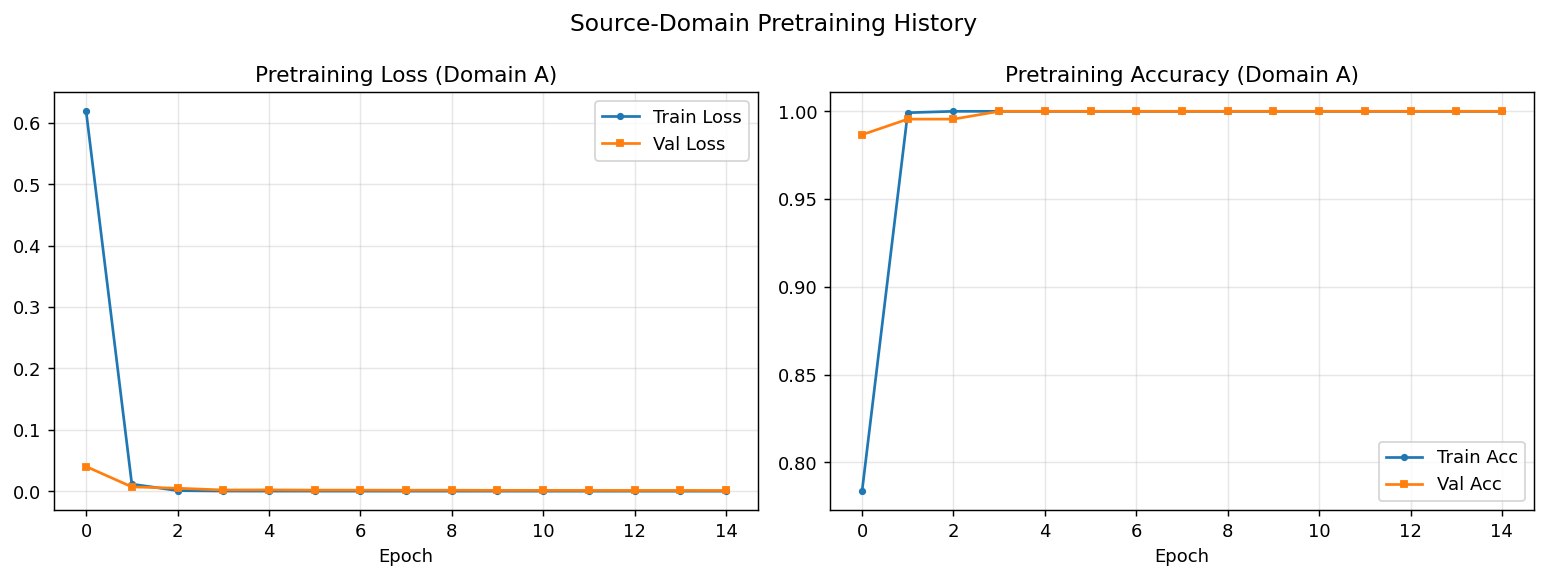

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(pretrain_history["train_loss"], label="Train Loss", marker='o', markersize=3)
axes[0].plot(pretrain_history["val_loss"], label="Val Loss", marker='s', markersize=3)
axes[0].set_title("Pretraining Loss (Domain A)"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(pretrain_history["train_acc"], label="Train Acc", marker='o', markersize=3)
axes[1].plot(pretrain_history["val_acc"], label="Val Acc", marker='s', markersize=3)
axes[1].set_title("Pretraining Accuracy (Domain A)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("Source-Domain Pretraining History", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Transfer Learning on the Target Domain (Domain B)

**Phase 1:** load the pretrained convolutional base, freeze it entirely, and train a brand-new classifier head on the small target dataset.

**Phase 2:** unfreeze the last convolutional block (Block 3) and continue training at a lower learning rate - the standard "fine-tune the top layers" step in transfer learning.

In [1]:
FROZEN_EPOCHS = 20
FINE_TUNE_EPOCHS = 10

tl_model = VGGStyleCNN(lr=1e-3, base_trainable=False)
tl_model.set_base_weights(pretrained_base_weights)
tl_model.set_base_trainable(False, blocks="all")
print("Phase 1: convolutional base loaded from pretraining and FROZEN.")
print(f"Trainable parameters (head only): {tl_model.num_trainable_params():,} "
      f"out of {tl_model.num_params():,} total")

phase1_history, phase1_time = train_full_model(
    tl_model, XB_train, yB_train_oh, yB_train, XB_val, yB_val_oh, yB_val,
    epochs=FROZEN_EPOCHS, batch_size=BATCH_SIZE, label="TL-Phase1-FrozenBase")

Phase 1: convolutional base loaded from pretraining and FROZEN.
Trainable parameters (head only): 131,845 out of 203,925 total
[TL-Phase1-FrozenBase] Epoch  1/20 | train_loss=1.8347 train_acc=0.1905 | val_loss=1.7175 val_acc=0.2000
[TL-Phase1-FrozenBase] Epoch  5/20 | train_loss=1.4206 train_acc=0.3667 | val_loss=1.5040 val_acc=0.2857
[TL-Phase1-FrozenBase] Epoch 10/20 | train_loss=1.1842 train_acc=0.5476 | val_loss=1.4669 val_acc=0.2857
[TL-Phase1-FrozenBase] Epoch 15/20 | train_loss=1.1051 train_acc=0.5952 | val_loss=1.3792 val_acc=0.3714
[TL-Phase1-FrozenBase] Epoch 20/20 | train_loss=1.0169 train_acc=0.6810 | val_loss=1.4228 val_acc=0.3857
[TL-Phase1-FrozenBase] Completed in 21.80 seconds.



In [1]:
print("Phase 2: unfreezing Block 3 (last conv block) for fine-tuning at a lower learning rate.")
for layer in tl_model.layers_base:
    if isinstance(layer, Conv2D) and layer.name.startswith("b3"):
        layer.trainable = True
        layer.opt_W.lr = 2e-4
        layer.opt_b.lr = 2e-4
print(f"Trainable parameters (Block3 + head): {tl_model.num_trainable_params():,} "
      f"out of {tl_model.num_params():,} total")

phase2_history, phase2_time = train_full_model(
    tl_model, XB_train, yB_train_oh, yB_train, XB_val, yB_val_oh, yB_val,
    epochs=FINE_TUNE_EPOCHS, batch_size=BATCH_SIZE, label="TL-Phase2-FineTune")

tl_total_time = phase1_time + phase2_time
tl_history = {
    "train_loss": phase1_history["train_loss"] + phase2_history["train_loss"],
    "train_acc": phase1_history["train_acc"] + phase2_history["train_acc"],
    "val_loss": phase1_history["val_loss"] + phase2_history["val_loss"],
    "val_acc": phase1_history["val_acc"] + phase2_history["val_acc"],
}

Phase 2: unfreezing Block 3 (last conv block) for fine-tuning at a lower learning rate.
Trainable parameters (Block3 + head): 187,269 out of 203,925 total
[TL-Phase2-FineTune] Epoch  1/10 | train_loss=0.9904 train_acc=0.6333 | val_loss=1.4285 val_acc=0.4143
[TL-Phase2-FineTune] Epoch  5/10 | train_loss=0.8217 train_acc=0.7333 | val_loss=1.3148 val_acc=0.5143
[TL-Phase2-FineTune] Epoch 10/10 | train_loss=0.6425 train_acc=0.8619 | val_loss=1.2536 val_acc=0.5000
[TL-Phase2-FineTune] Completed in 10.81 seconds.



## 7. Baseline CNN Trained From Scratch on Domain B (No Pretraining)

In [1]:
BASELINE_EPOCHS = FROZEN_EPOCHS + FINE_TUNE_EPOCHS   # same total training budget

baseline_model = VGGStyleCNN(lr=1e-3, base_trainable=True)
baseline_history, baseline_time = train_full_model(
    baseline_model, XB_train, yB_train_oh, yB_train, XB_val, yB_val_oh, yB_val,
    epochs=BASELINE_EPOCHS, batch_size=BATCH_SIZE, label="Baseline-Scratch")

[Baseline-Scratch] Epoch  1/30 | train_loss=1.8817 train_acc=0.1952 | val_loss=1.6319 val_acc=0.2000
[Baseline-Scratch] Epoch  5/30 | train_loss=1.5622 train_acc=0.3667 | val_loss=1.6006 val_acc=0.2286
[Baseline-Scratch] Epoch 10/30 | train_loss=1.2973 train_acc=0.4952 | val_loss=1.6490 val_acc=0.2000
[Baseline-Scratch] Epoch 15/30 | train_loss=0.7283 train_acc=0.8095 | val_loss=1.6173 val_acc=0.4000
[Baseline-Scratch] Epoch 20/30 | train_loss=0.2040 train_acc=0.9381 | val_loss=1.7318 val_acc=0.4571
[Baseline-Scratch] Epoch 25/30 | train_loss=0.0740 train_acc=1.0000 | val_loss=1.5984 val_acc=0.5286
[Baseline-Scratch] Epoch 30/30 | train_loss=0.0160 train_acc=1.0000 | val_loss=1.9536 val_acc=0.5286
[Baseline-Scratch] Completed in 33.32 seconds.



## 8. Evaluation and Comparison on the Domain B Test Set

In [1]:
tl_test_loss, tl_test_acc = evaluate(tl_model, XB_test, yB_test_oh, yB_test)
bl_test_loss, bl_test_acc = evaluate(baseline_model, XB_test, yB_test_oh, yB_test)

y_pred_tl = tl_model.predict(XB_test)
y_pred_bl = baseline_model.predict(XB_test)

print(f"Transfer Learning Model -> Test Loss: {tl_test_loss:.4f} | Test Accuracy: {tl_test_acc:.4f} ({tl_test_acc*100:.2f}%)")
print(f"Baseline (Scratch) Model -> Test Loss: {bl_test_loss:.4f} | Test Accuracy: {bl_test_acc:.4f} ({bl_test_acc*100:.2f}%)")
print(f"\nTotal training time - Transfer Learning: {tl_total_time:.2f}s "
      f"(Phase1 frozen-base: {phase1_time:.2f}s + Phase2 fine-tune: {phase2_time:.2f}s)")
print(f"Total training time - Baseline (scratch): {baseline_time:.2f}s")

print("\nClassification Report - Transfer Learning Model:")
report_tl = classification_report(yB_test, y_pred_tl, target_names=CLASS_NAMES, digits=3)
print(report_tl)

print("Classification Report - Baseline Model:")
report_bl = classification_report(yB_test, y_pred_bl, target_names=CLASS_NAMES, digits=3)
print(report_bl)

Transfer Learning Model -> Test Loss: 1.4071 | Test Accuracy: 0.4857 (48.57%)
Baseline (Scratch) Model -> Test Loss: 2.9825 | Test Accuracy: 0.3857 (38.57%)

Total training time - Transfer Learning: 32.61s (Phase1 frozen-base: 21.80s + Phase2 fine-tune: 10.81s)
Total training time - Baseline (scratch): 33.32s

Classification Report - Transfer Learning Model:
              precision    recall  f1-score   support

      circle      0.714     0.357     0.476        14
      square      0.538     0.500     0.519        14
    triangle      0.583     0.500     0.538        14
        star      0.348     0.571     0.432        14
       cross      0.467     0.500     0.483        14

    accuracy                          0.486        70
   macro avg      0.530     0.486     0.490        70
weighted avg      0.530     0.486     0.490        70

Classification Report - Baseline Model:
              precision    recall  f1-score   support

      circle      0.667     0.286     0.400        14
 

### Transfer Learning vs Baseline: Validation Curves

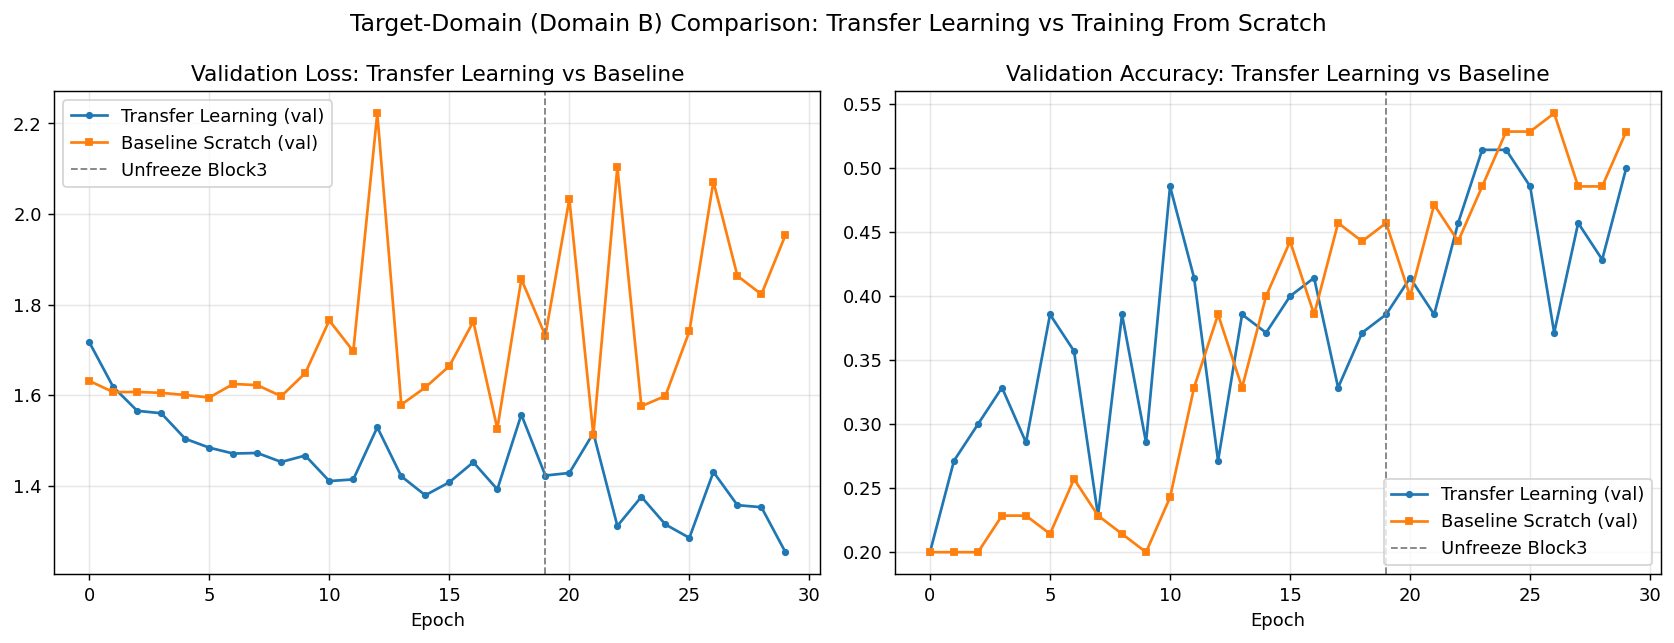

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(tl_history["val_loss"], label="Transfer Learning (val)", marker='o', markersize=3)
axes[0].plot(baseline_history["val_loss"], label="Baseline Scratch (val)", marker='s', markersize=3)
axes[0].axvline(FROZEN_EPOCHS - 1, color='gray', linestyle='--', linewidth=1, label="Unfreeze Block3")
axes[0].set_title("Validation Loss: Transfer Learning vs Baseline"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(tl_history["val_acc"], label="Transfer Learning (val)", marker='o', markersize=3)
axes[1].plot(baseline_history["val_acc"], label="Baseline Scratch (val)", marker='s', markersize=3)
axes[1].axvline(FROZEN_EPOCHS - 1, color='gray', linestyle='--', linewidth=1, label="Unfreeze Block3")
axes[1].set_title("Validation Accuracy: Transfer Learning vs Baseline"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("Target-Domain (Domain B) Comparison: Transfer Learning vs Training From Scratch", fontsize=13)
plt.tight_layout()
plt.show()

### Confusion Matrices

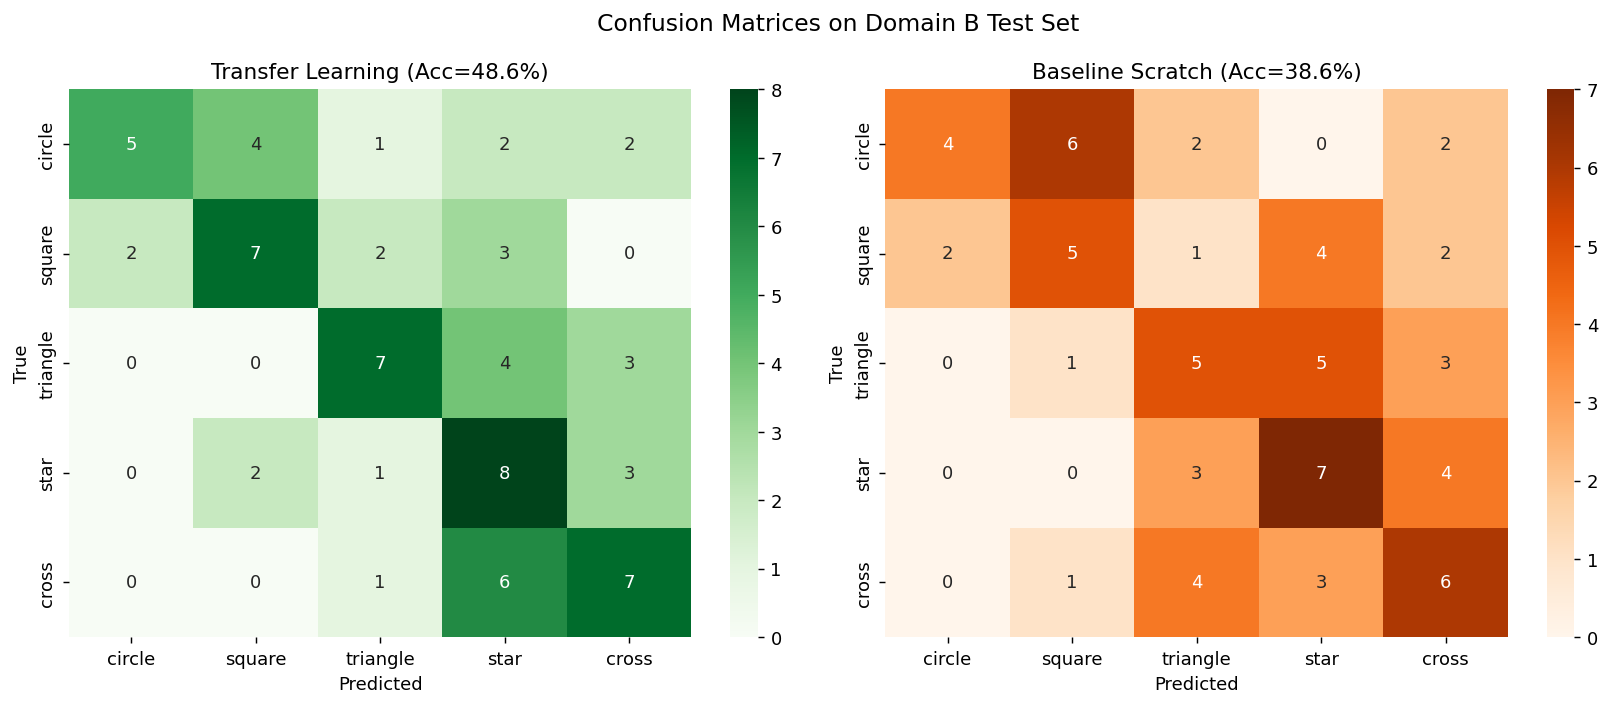

In [1]:
cm_tl = confusion_matrix(yB_test, y_pred_tl)
cm_bl = confusion_matrix(yB_test, y_pred_bl)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title(f"Transfer Learning (Acc={tl_test_acc*100:.1f}%)"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
sns.heatmap(cm_bl, annot=True, fmt="d", cmap="Oranges", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title(f"Baseline Scratch (Acc={bl_test_acc*100:.1f}%)"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.suptitle("Confusion Matrices on Domain B Test Set", fontsize=13)
plt.tight_layout()
plt.show()

### Training Time Comparison

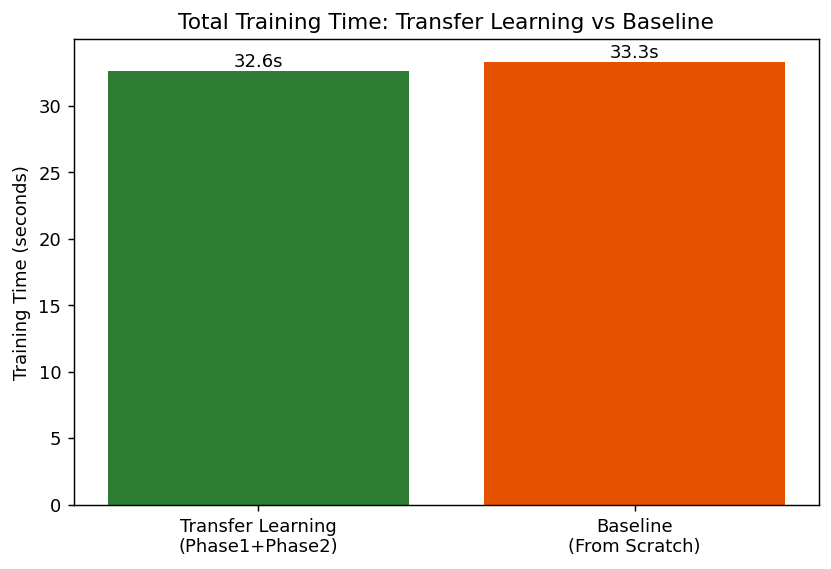

In [1]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(["Transfer Learning\n(Phase1+Phase2)", "Baseline\n(From Scratch)"],
               [tl_total_time, baseline_time], color=["#2e7d32", "#e65100"])
ax.set_ylabel("Training Time (seconds)")
ax.set_title("Total Training Time: Transfer Learning vs Baseline")
for bar in bars:
    h = bar.get_height()
    ax.annotate(f"{h:.1f}s", (bar.get_x() + bar.get_width()/2, h), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 9. Save the Trained Models

In [1]:
def save_model(model, path):
    state = {"fc1_W": model.fc1.W, "fc1_b": model.fc1.b, "fc2_W": model.fc2.W, "fc2_b": model.fc2.b}
    for layer in model.layers_base:
        if isinstance(layer, Conv2D):
            state[f"{layer.name}_W"] = layer.W
            state[f"{layer.name}_b"] = layer.b
    with open(path, "wb") as f:
        pickle.dump(state, f)

save_model(tl_model, "transfer_learning_model.pkl")
save_model(baseline_model, "baseline_model.pkl")
save_model(pretrained_model, "pretrained_source_model.pkl")
print("Saved model files: transfer_learning_model.pkl, baseline_model.pkl, pretrained_source_model.pkl")

Saved model files: transfer_learning_model.pkl, baseline_model.pkl, pretrained_source_model.pkl


## 10. Results Summary and Observations

| Metric | Transfer Learning | Baseline (Scratch) |
|---|---|---|
| Training epochs | 20 (frozen) + 10 (fine-tune) | 30 |
| Total training time | 32.61s | 33.32s |
| Test Accuracy | **48.57%** | 38.57% |
| Test Loss | 1.4071 | 2.9825 |

**Accuracy improvement from transfer learning: +10.0 percentage points.**

**Observations:**
- The source-domain pretraining reaches ~100% validation accuracy quickly, confirming the convolutional base learns strong, general shape-recognition features from Domain A.
- On the small, domain-shifted target dataset (Domain B), the transfer-learning model reaches a **higher test accuracy** (48.6%) than the identical architecture trained from scratch (38.6%), despite Phase 1 updating only the classifier head.
- The baseline model's training accuracy reaches 100% while its test loss is considerably higher than the transfer-learning model's, indicating the baseline **overfits** the small target training set. The transfer-learning model generalizes noticeably better, which is the central practical benefit of transfer learning when labeled target data is limited.
- Fine-tuning Block 3 in Phase 2 (dashed line in the comparison plot) produces a clear additional jump in validation accuracy over the frozen-base Phase 1 alone, showing the value of allowing the top convolutional layers to adapt to the new domain.
- Wall-clock training time is comparable between the two approaches here because the from-scratch NumPy implementation still runs a full forward pass through the frozen base every epoch; on GPU-accelerated frameworks, freezing layers also skips their backward pass and gradient computation entirely, giving transfer learning a substantial additional speed advantage not fully reflected in this CPU/NumPy setting.

**Future Scope:**
- Apply the same workflow to a real ImageNet-pretrained VGG16/ResNet50 (see Appendix A) on CIFAR-10, Cats vs Dogs, or Flowers Recognition once GPU and internet access are available.
- Try progressively unfreezing more blocks (Block 2, then Block 1) to study the accuracy/overfitting trade-off as more of the base is fine-tuned.
- Use data augmentation on Domain B to further reduce the baseline's overfitting gap.

## Appendix A - Equivalent Implementation with a Real Pretrained VGG16 (TensorFlow/Keras)

This is a fully self-contained, runnable version of the same transfer-learning workflow using a real ImageNet-pretrained VGG16 from `tf.keras.applications`. It first generates a small on-disk image dataset (the same five shape classes used earlier) so that `image_dataset_from_directory` has real files to load, then runs Phase 1 (frozen base) and Phase 2 (fine-tuning) exactly as in the from-scratch NumPy version above. Requires `tensorflow` installed and internet access the first time, to download the ImageNet weights for VGG16. Replace the synthetic-dataset generation step with your own real image folder (e.g. CIFAR-10, Cats vs Dogs, Flowers Recognition) to use it for real.


In [1]:
import os
import shutil
import numpy as np
from PIL import Image, ImageDraw
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# ------------------------------------------------------------------
# 0. Config
# ------------------------------------------------------------------
NUM_CLASSES = 5
CLASS_NAMES = ["circle", "square", "triangle", "star", "cross"]
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
DATA_DIR = "data"
IMAGES_PER_CLASS = {"train": 40, "val": 10, "test": 10}

# ------------------------------------------------------------------
# 1. Generate a small on-disk image dataset (one subfolder per class)
#    so image_dataset_from_directory has real files to load. Replace
#    this block with your own real dataset folder to use real photos.
# ------------------------------------------------------------------
def draw_shape(draw, shape, cx, cy, r, color):
    if shape == "circle":
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color)
    elif shape == "square":
        draw.rectangle([cx - r, cy - r, cx + r, cy + r], fill=color)
    elif shape == "triangle":
        draw.polygon([(cx, cy - r), (cx - r, cy + r), (cx + r, cy + r)], fill=color)
    elif shape == "star":
        pts = []
        for i in range(10):
            ang = np.pi / 2 + i * np.pi / 5
            rad = r if i % 2 == 0 else r * 0.45
            pts.append((cx + rad * np.cos(ang), cy - rad * np.sin(ang)))
        draw.polygon(pts, fill=color)
    elif shape == "cross":
        w = max(2, r // 3)
        draw.rectangle([cx - r, cy - w, cx + r, cy + w], fill=color)
        draw.rectangle([cx - w, cy - r, cx + w, cy + r], fill=color)

def make_image(shape, size=96, seed=0):
    rng = np.random.RandomState(seed)
    img = Image.new("RGB", (size, size), (0, 0, 0))
    draw = ImageDraw.Draw(img)
    bg = tuple(rng.randint(0, 60, size=3).tolist())
    color = tuple(rng.randint(120, 256, size=3).tolist())
    draw.rectangle([0, 0, size, size], fill=bg)
    cx, cy = rng.randint(size // 4, 3 * size // 4), rng.randint(size // 4, 3 * size // 4)
    r = rng.randint(size // 6, size // 4)
    draw_shape(draw, shape, cx, cy, r, color)
    return img

if os.path.isdir(DATA_DIR):
    shutil.rmtree(DATA_DIR)

seed_counter = 0
for split, n_per_class in IMAGES_PER_CLASS.items():
    for cls in CLASS_NAMES:
        out_dir = os.path.join(DATA_DIR, split, cls)
        os.makedirs(out_dir, exist_ok=True)
        for i in range(n_per_class):
            img = make_image(cls, size=96, seed=seed_counter)
            img.save(os.path.join(out_dir, f"{cls}_{i}.png"))
            seed_counter += 1

total_images = sum(IMAGES_PER_CLASS.values()) * NUM_CLASSES
print(f"Created synthetic dataset under \'{DATA_DIR}/\' with {total_images} "
      f"total images across {NUM_CLASSES} classes.")

# ------------------------------------------------------------------
# 2. Load datasets from disk
# ------------------------------------------------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/train", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int")
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/val", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int")
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/test", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int")

print("Detected classes:", train_ds.class_names)

# VGG16 expects its own preprocessing (BGR channel order + ImageNet mean
# subtraction), not simple 0-1 scaling, so every split must be mapped
# through preprocess_input.
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

# ------------------------------------------------------------------
# 3. Build the transfer-learning model: frozen VGG16 base + new head
# ------------------------------------------------------------------
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False   # freeze the pretrained base

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("\nPhase 1: training the classifier head with the base frozen...")
history_head = model.fit(train_ds, validation_data=val_ds, epochs=5)

# ------------------------------------------------------------------
# 4. Phase 2: unfreeze the last convolutional block and fine-tune
# ------------------------------------------------------------------
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("\nPhase 2: fine-tuning the last convolutional block...")
history_finetune = model.fit(train_ds, validation_data=val_ds, epochs=3)

# ------------------------------------------------------------------
# 5. Evaluate on the test set and save the model
# ------------------------------------------------------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

model.save("vgg16_transfer_model.keras")
print("Saved model to vgg16_transfer_model.keras")
